In [ ]:
# importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Style global
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
COLORS = ['#1a6fb5', '#e05a2b', '#2ca05a', '#8b4fa0', '#d4a017', '#c0392b']

In [9]:
# ── Chargement des données ─────────────────────────────────
PATH = "/mnt/user-data/outputs/data/raw/"
ROUTES = "/mnt/user-data/outputs/data/routes/"

lpi   = pd.read_csv("LPI_Global_Ranking.csv")
wpi   = pd.read_csv("world_port_index.csv")
trade = pd.read_csv("trade_flows_global.csv")
suez  = pd.read_csv("suez_canal_traffic.csv")
routes= pd.read_csv("routes_ports_villes.csv")

suez['date'] = pd.to_datetime(suez['date'])

print("✅ Données chargées")


✅ Données chargées


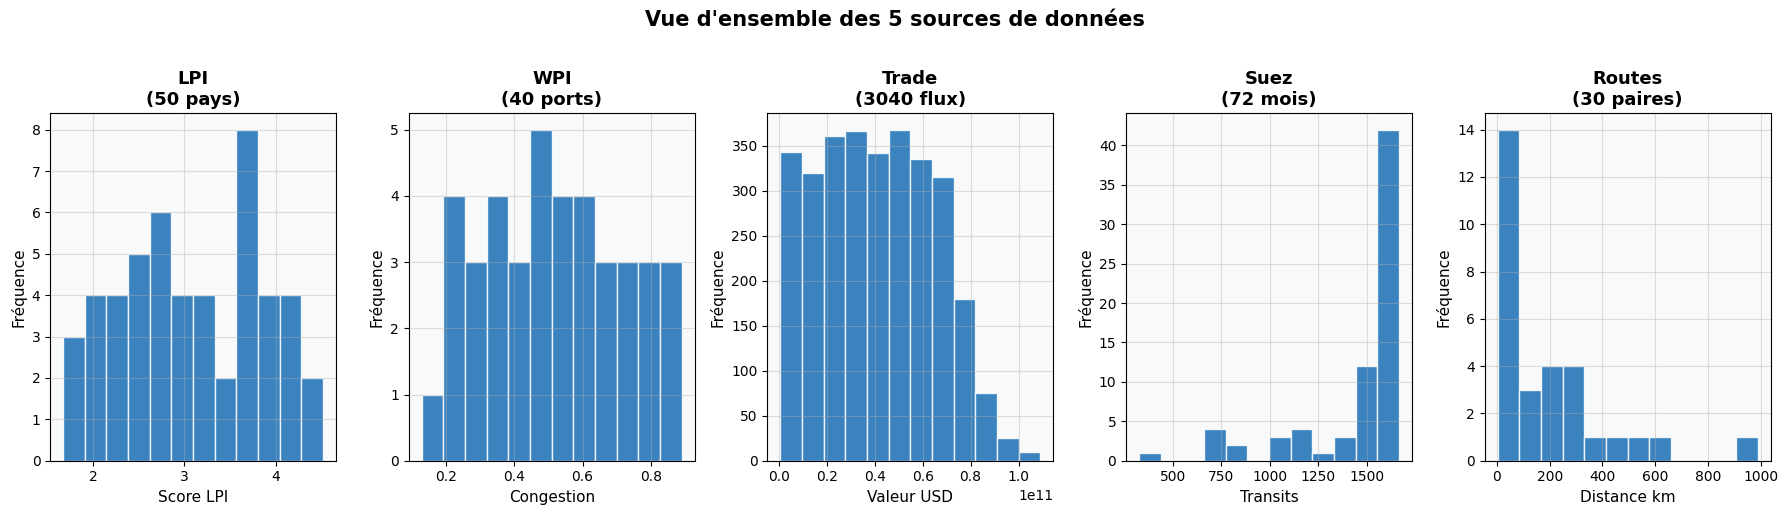

✅ Fig 1 — Overview


In [23]:
# FIGURE 1 — Vue d'ensemble des 5 datasets
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Vue d'ensemble des 5 sources de données", fontsize=15, fontweight='bold', y=1.02)

datasets = [
    (lpi,    "LPI\n(50 pays)",     "lpi_score",       "Score LPI"),
    (wpi,    "WPI\n(40 ports)",    "congestion_index","Congestion"),
    (trade,  "Trade\n(3040 flux)", "trade_value_usd", "Valeur USD"),
    (suez,   "Suez\n(72 mois)",    "total_transits",  "Transits"),
    (routes, "Routes\n(30 paires)","distance_km",     "Distance km"),
]

for ax, (df, title, col, xlabel) in zip(axes, datasets):
    ax.hist(df[col], bins=12, color=COLORS[0], edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fréquence")

import os

os.makedirs("figures", exist_ok=True)

plt.tight_layout()
plt.savefig("figures/fig1_overview.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()

print("✅ Fig 1 — Overview")


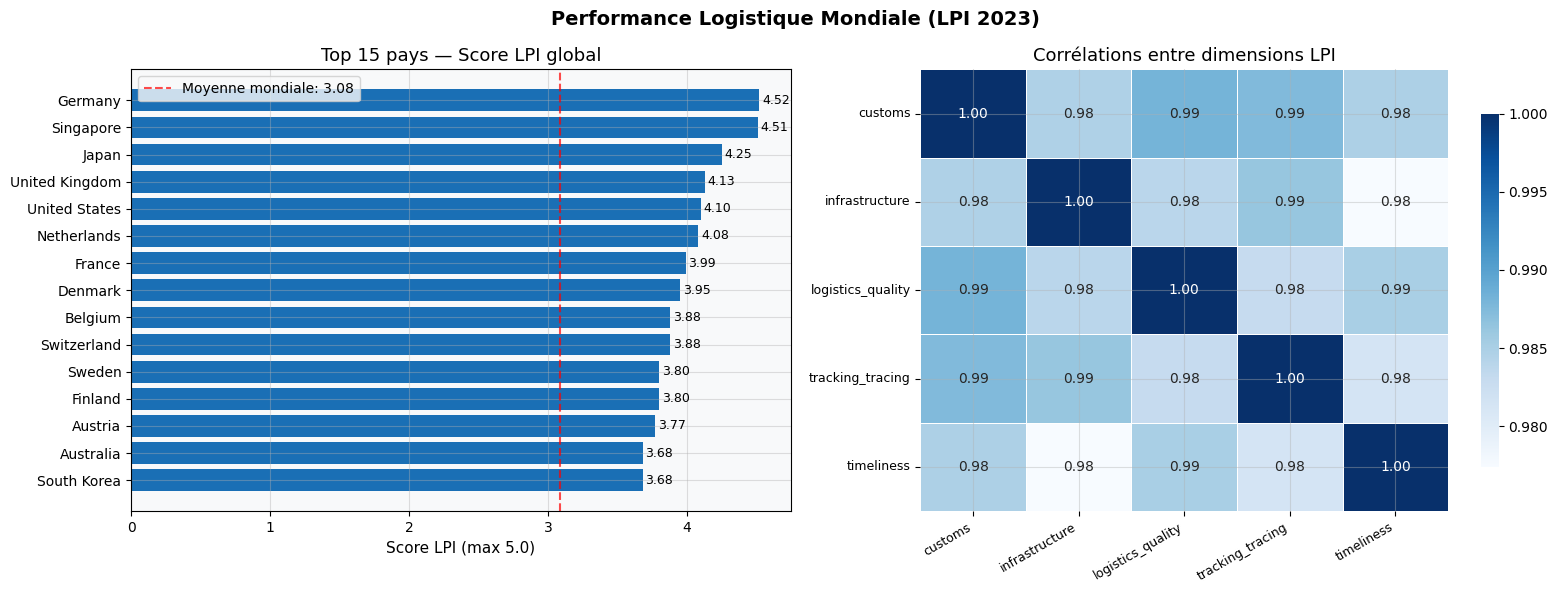

✅ Fig 2 — LPI


In [24]:
# FIGURE 2 — LPI : Top 15 pays + corrélations dimensions
# ══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Performance Logistique Mondiale (LPI 2023)", fontsize=14, fontweight='bold')

# Top 15
top15 = lpi.nlargest(15, 'lpi_score')
bars = ax1.barh(top15['country'][::-1], top15['lpi_score'][::-1],
                color=[COLORS[0] if c != 'Morocco' else COLORS[1] for c in top15['country'][::-1]])
ax1.axvline(lpi['lpi_score'].mean(), color='red', linestyle='--', alpha=0.7, label=f"Moyenne mondiale: {lpi['lpi_score'].mean():.2f}")
ax1.set_xlabel("Score LPI (max 5.0)")
ax1.set_title("Top 15 pays — Score LPI global")
ax1.legend()
for bar, val in zip(bars, top15['lpi_score'][::-1]):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)

# Corrélation entre dimensions LPI
dims = ['customs', 'infrastructure', 'logistics_quality', 'tracking_tracing', 'timeliness']
corr = lpi[dims].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            cbar_kws={'shrink': 0.8}, linewidths=0.5)
ax2.set_title("Corrélations entre dimensions LPI")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("figures/fig2_lpi.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 2 — LPI")

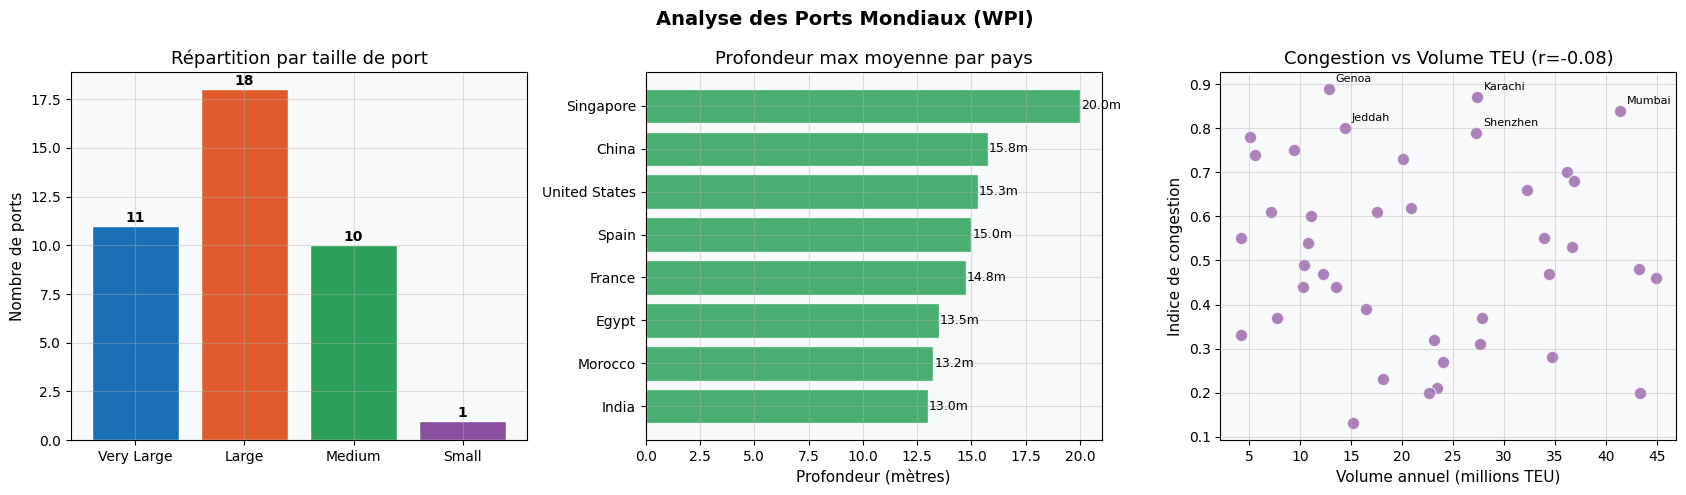

✅ Fig 3 — WPI


In [25]:
# FIGURE 3 — World Port Index : Ports par taille + profondeur
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Analyse des Ports Mondiaux (WPI)", fontsize=14, fontweight='bold')

# Distribution taille
size_order = ['VL', 'L', 'M', 'S']
size_labels = {'VL': 'Very Large', 'L': 'Large', 'M': 'Medium', 'S': 'Small'}
counts = wpi['harbor_size'].value_counts().reindex(size_order, fill_value=0)
axes[0].bar([size_labels[s] for s in counts.index], counts.values,
            color=COLORS[:4], edgecolor='white')
axes[0].set_title("Répartition par taille de port")
axes[0].set_ylabel("Nombre de ports")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Profondeur max par région (top pays)
top_countries = wpi['country'].value_counts().head(8).index
wpi_top = wpi[wpi['country'].isin(top_countries)]
avg_depth = wpi_top.groupby('country')['max_depth'].mean().sort_values(ascending=True)
axes[1].barh(avg_depth.index, avg_depth.values, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].set_title("Profondeur max moyenne par pays")
axes[1].set_xlabel("Profondeur (mètres)")
for i, v in enumerate(avg_depth.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}m', va='center', fontsize=9)

# Congestion vs TEU
axes[2].scatter(wpi['annual_teu_millions'], wpi['congestion_index'],
                c=COLORS[3], alpha=0.7, s=80, edgecolors='white')
for _, row in wpi.nlargest(5, 'congestion_index').iterrows():
    axes[2].annotate(row['port_name'].replace('Port of ', ''),
                     (row['annual_teu_millions'], row['congestion_index']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
r, p = stats.pearsonr(wpi['annual_teu_millions'], wpi['congestion_index'])
axes[2].set_title(f"Congestion vs Volume TEU (r={r:.2f})")
axes[2].set_xlabel("Volume annuel (millions TEU)")
axes[2].set_ylabel("Indice de congestion")

plt.tight_layout()
plt.savefig("figures/fig3_wpi.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 3 — WPI")

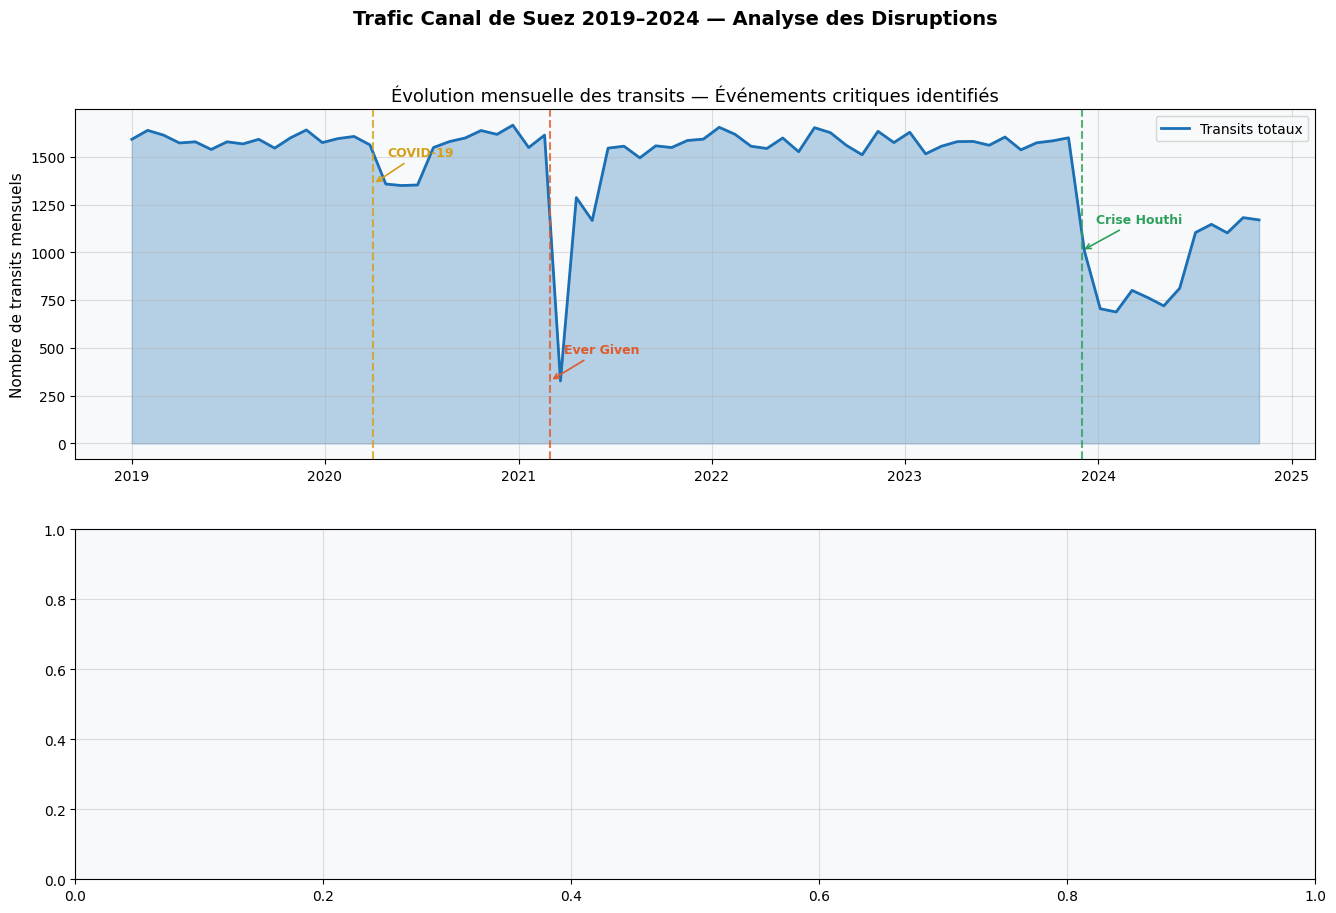

In [26]:
# FIGURE 4 — Trafic Canal de Suez 2019–2024
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Trafic Canal de Suez 2019–2024 — Analyse des Disruptions", fontsize=14, fontweight='bold')

# Série temporelle
ax = axes[0]
ax.fill_between(suez['date'], suez['total_transits'],
                alpha=0.3, color=COLORS[0])
ax.plot(suez['date'], suez['total_transits'],
        color=COLORS[0], linewidth=2, label='Transits totaux')

# Événements
events = {
    '2020-04-01': ('COVID-19', COLORS[4]),
    '2021-03-01': ('Ever Given', COLORS[1]),
    '2023-12-01': ('Crise Houthi', COLORS[2]),
}
for date_str, (label, color) in events.items():
    d = pd.Timestamp(date_str)
    val = suez[suez['date'] >= d]['total_transits'].iloc[0]
    ax.axvline(d, color=color, linestyle='--', alpha=0.8, linewidth=1.5)
    ax.annotate(label, xy=(d, val), xytext=(10, 20),
                textcoords='offset points', fontsize=9,
                color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.set_ylabel("Nombre de transits mensuels")
ax.set_title("Évolution mensuelle des transits — Événements critiques identifiés")
ax.legend()

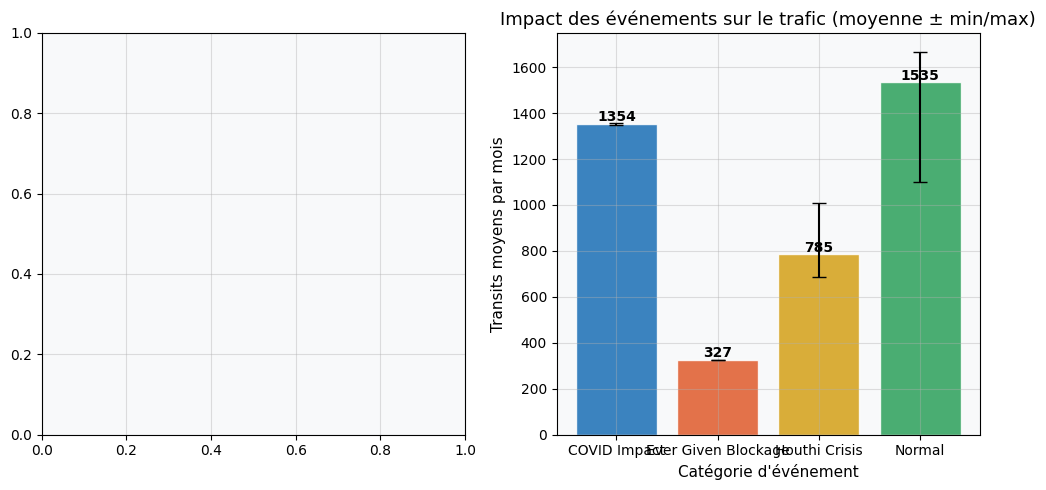

✅ Fig 4 — Suez


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Comparaison par événement
ax2 = axes[1]

suez_grouped = suez.groupby('event_flag')['total_transits'].agg(['mean', 'min', 'max'])

colors_ev = [COLORS[0], COLORS[1], COLORS[4], COLORS[2]]

bars = ax2.bar(
    suez_grouped.index,
    suez_grouped['mean'],
    color=colors_ev[:len(suez_grouped)],
    edgecolor='white',
    alpha=0.85
)

ax2.errorbar(
    suez_grouped.index,
    suez_grouped['mean'],
    yerr=[
        suez_grouped['mean'] - suez_grouped['min'],
        suez_grouped['max'] - suez_grouped['mean']
    ],
    fmt='none',
    color='black',
    capsize=5,
    linewidth=1.5
)

ax2.set_title("Impact des événements sur le trafic (moyenne ± min/max)")
ax2.set_ylabel("Transits moyens par mois")
ax2.set_xlabel("Catégorie d'événement")

for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{bar.get_height():.0f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.savefig("figures/fig4_suez.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()

print("✅ Fig 4 — Suez")

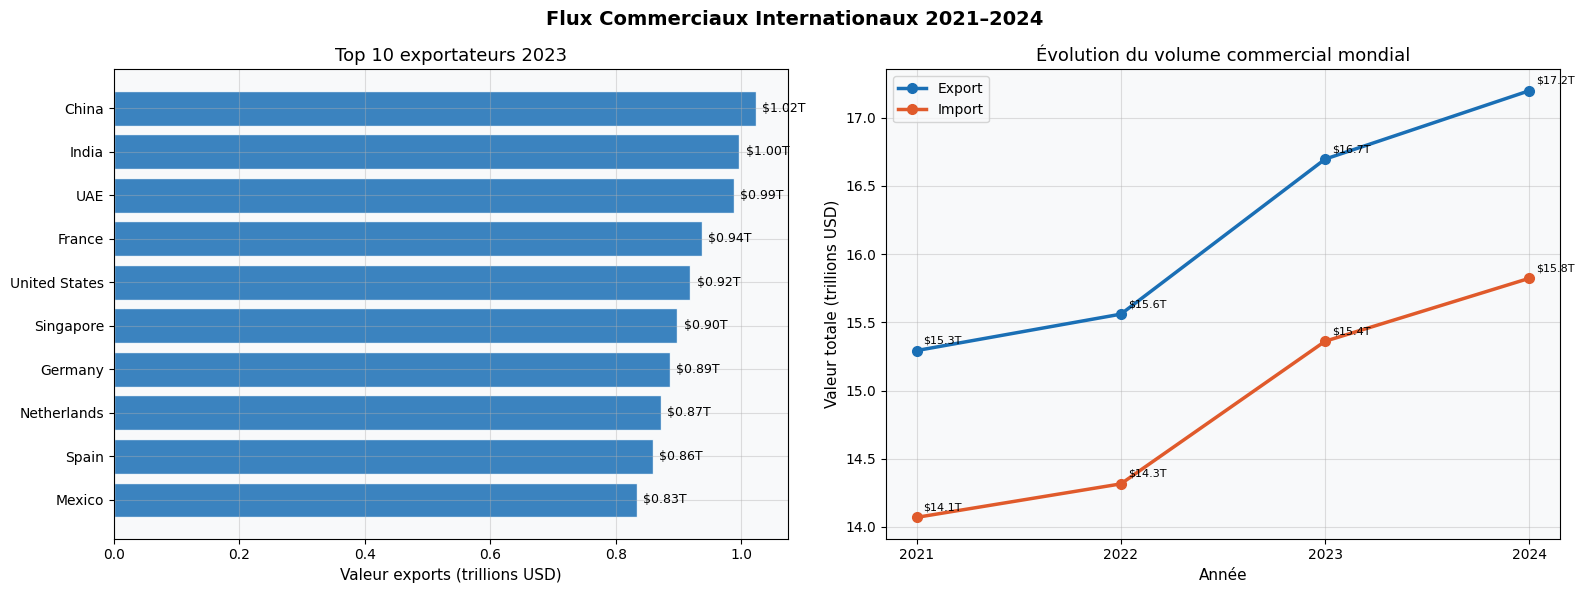

✅ Fig 5 — Trade


In [31]:
# FIGURE 5 — Flux commerciaux mondiaux
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Flux Commerciaux Internationaux 2021–2024", fontsize=14, fontweight='bold')

# Top exportateurs 2023
exports_2023 = (trade[(trade['year'] == 2023) & (trade['flow'] == 'Export')]
                .groupby('reporter')['trade_value_usd'].sum()
                .nlargest(10).sort_values())
axes[0].barh(exports_2023.index, exports_2023.values / 1e12,
             color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].set_title("Top 10 exportateurs 2023")
axes[0].set_xlabel("Valeur exports (trillions USD)")
for i, v in enumerate(exports_2023.values / 1e12):
    axes[0].text(v + 0.01, i, f'${v:.2f}T', va='center', fontsize=9)

# Évolution du commerce mondial
trade_yearly = (trade.groupby(['year', 'flow'])['trade_value_usd']
                .sum().reset_index())
for flow, color in [('Export', COLORS[0]), ('Import', COLORS[1])]:
    d = trade_yearly[trade_yearly['flow'] == flow]
    axes[1].plot(d['year'], d['trade_value_usd'] / 1e12,
                 marker='o', color=color, linewidth=2.5,
                 markersize=7, label=flow)
    for _, row in d.iterrows():
        axes[1].annotate(f"${row['trade_value_usd']/1e12:.1f}T",
                        (row['year'], row['trade_value_usd']/1e12),
                        textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].set_title("Évolution du volume commercial mondial")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Valeur totale (trillions USD)")
axes[1].legend()
axes[1].set_xticks([2021, 2022, 2023, 2024])

plt.tight_layout()
plt.savefig("figures/fig5_trade.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 5 — Trade")


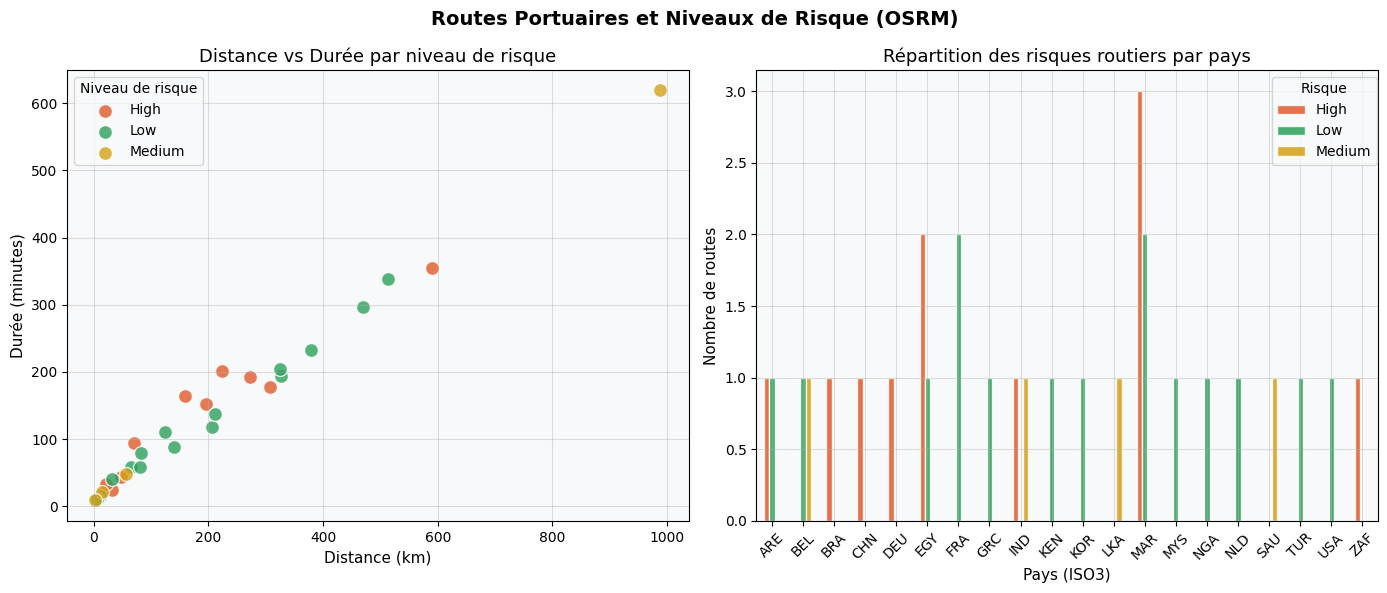

✅ Fig 6 — Routes


In [32]:
# FIGURE 6 — Routes OSRM + Analyse des risques
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Routes Portuaires et Niveaux de Risque (OSRM)", fontsize=14, fontweight='bold')

# Distance vs Durée coloré par risque
risk_colors = {'Low': COLORS[2], 'Medium': COLORS[4], 'High': COLORS[1]}
for risk, grp in routes.groupby('risk_level'):
    axes[0].scatter(grp['distance_km'], grp['duration_minutes'],
                    c=risk_colors.get(risk, 'gray'),
                    label=risk, s=100, alpha=0.8, edgecolors='white')
axes[0].set_title("Distance vs Durée par niveau de risque")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Durée (minutes)")
axes[0].legend(title="Niveau de risque")

# Répartition des risques par pays
risk_by_country = (routes.groupby(['country_iso', 'risk_level'])
                   .size().unstack(fill_value=0))
risk_by_country.plot(kind='bar', ax=axes[1],
                     color=[risk_colors.get(c, 'gray') for c in risk_by_country.columns],
                     edgecolor='white', alpha=0.85)
axes[1].set_title("Répartition des risques routiers par pays")
axes[1].set_xlabel("Pays (ISO3)")
axes[1].set_ylabel("Nombre de routes")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Risque", bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig("figures/fig6_routes.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 6 — Routes")

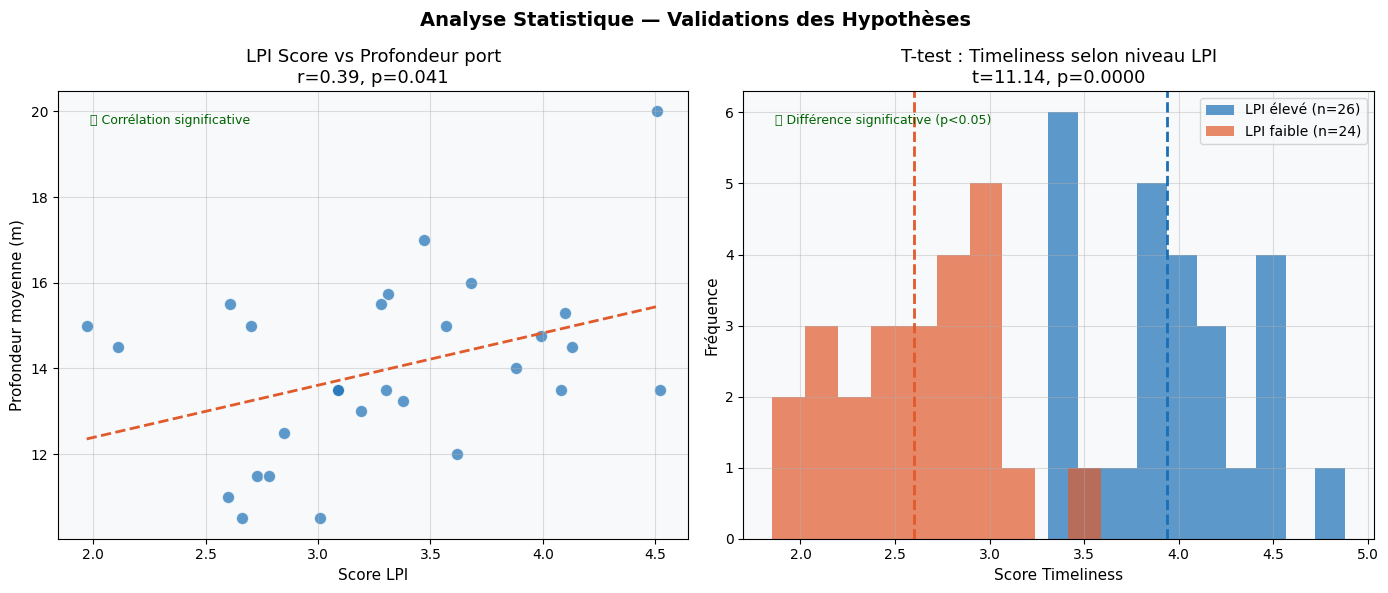

✅ Fig 7 — Stats


In [33]:
# FIGURE 7 — Analyse statistique : Tests & Corrélations
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analyse Statistique — Validations des Hypothèses", fontsize=14, fontweight='bold')

# Test corrélation LPI vs Profondeur port (via iso3 commun)
merged = pd.merge(lpi, wpi.groupby('iso3')['max_depth'].mean().reset_index(), on='iso3')
r, p = stats.pearsonr(merged['lpi_score'], merged['max_depth'])
axes[0].scatter(merged['lpi_score'], merged['max_depth'],
                c=COLORS[0], s=80, alpha=0.7, edgecolors='white')
m, b = np.polyfit(merged['lpi_score'], merged['max_depth'], 1)
x_line = np.linspace(merged['lpi_score'].min(), merged['lpi_score'].max(), 50)
axes[0].plot(x_line, m*x_line + b, color=COLORS[1], linewidth=2, linestyle='--')
axes[0].set_title(f"LPI Score vs Profondeur port\nr={r:.2f}, p={p:.3f}")
axes[0].set_xlabel("Score LPI")
axes[0].set_ylabel("Profondeur moyenne (m)")
sig = "✅ Corrélation significative" if p < 0.05 else "⚠️ Non significatif"
axes[0].text(0.05, 0.95, sig, transform=axes[0].transAxes,
             fontsize=9, va='top', color='darkgreen' if p < 0.05 else 'orange')

# Distribution LPI par groupe (high / low)
median_lpi = lpi['lpi_score'].median()
high = lpi[lpi['lpi_score'] >= median_lpi]['timeliness']
low  = lpi[lpi['lpi_score'] < median_lpi]['timeliness']
t_stat, p_val = stats.ttest_ind(high, low)
axes[1].hist(high, bins=10, alpha=0.7, color=COLORS[0], label=f'LPI élevé (n={len(high)})')
axes[1].hist(low,  bins=10, alpha=0.7, color=COLORS[1], label=f'LPI faible (n={len(low)})')
axes[1].axvline(high.mean(), color=COLORS[0], linestyle='--', linewidth=2)
axes[1].axvline(low.mean(),  color=COLORS[1], linestyle='--', linewidth=2)
axes[1].set_title(f"T-test : Timeliness selon niveau LPI\nt={t_stat:.2f}, p={p_val:.4f}")
axes[1].set_xlabel("Score Timeliness")
axes[1].set_ylabel("Fréquence")
axes[1].legend()
sig2 = "✅ Différence significative (p<0.05)" if p_val < 0.05 else "⚠️ Non significatif"
axes[1].text(0.05, 0.95, sig2, transform=axes[1].transAxes,
             fontsize=9, va='top', color='darkgreen' if p_val < 0.05 else 'orange')

plt.tight_layout()
plt.savefig("figures/fig7_stats.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 7 — Stats")

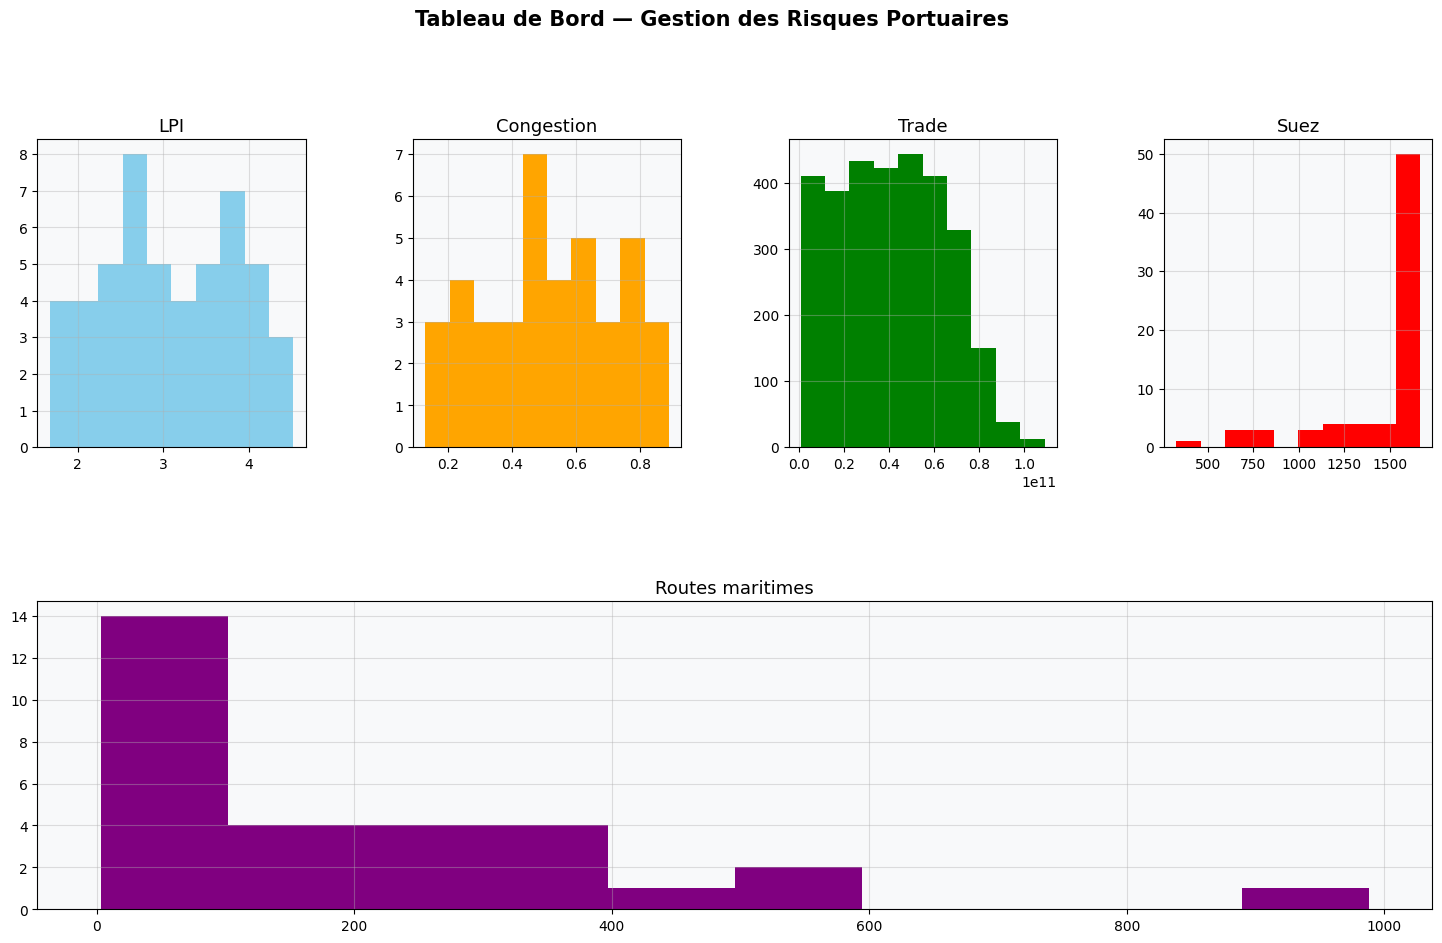

In [36]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "Tableau de Bord — Gestion des Risques Portuaires",
    fontsize=15,
    fontweight='bold',
    y=1.01
)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# 📊 Graphique 1
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(lpi['lpi_score'], color='skyblue')
ax1.set_title("LPI")

# 📊 Graphique 2
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(wpi['congestion_index'], color='orange')
ax2.set_title("Congestion")

# 📊 Graphique 3
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(trade['trade_value_usd'], color='green')
ax3.set_title("Trade")

# 📊 Graphique 4
ax4 = fig.add_subplot(gs[0, 3])
ax4.hist(suez['total_transits'], color='red')
ax4.set_title("Suez")

# 📊 Graphique 5 (ligne entière)
ax5 = fig.add_subplot(gs[1, :])
ax5.hist(routes['distance_km'], color='purple')
ax5.set_title("Routes maritimes")

plt.tight_layout()
plt.show()

In [37]:
# KPI 1 — Score LPI Maroc
ax_k1 = fig.add_subplot(gs[0, 0])
mar_lpi = lpi[lpi['iso3'] == 'MAR']['lpi_score'].values[0]
world_avg = lpi['lpi_score'].mean()
ax_k1.barh(['Maroc', 'Monde avg'], [mar_lpi, world_avg],
           color=[COLORS[1], COLORS[0]], edgecolor='white')
ax_k1.set_title("Score LPI — Maroc", fontsize=11)
ax_k1.set_xlim(0, 5)
for i, v in enumerate([mar_lpi, world_avg]):
    ax_k1.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')

In [38]:
# KPI 2 — Ports critiques (congestion > 0.6)
ax_k2 = fig.add_subplot(gs[0, 1])
critical = wpi[wpi['congestion_index'] > 0.6].nlargest(6, 'congestion_index')
ax_k2.barh(critical['port_name'].str.replace('Port of ', ''),
           critical['congestion_index'], color=COLORS[1], edgecolor='white', alpha=0.85)
ax_k2.set_title("Ports à forte congestion", fontsize=11)
ax_k2.set_xlabel("Indice congestion")
ax_k2.axvline(0.6, color='red', linestyle='--', alpha=0.6)

In [39]:
# KPI 3 — Trafic Suez : avant vs après crise
ax_k3 = fig.add_subplot(gs[0, 2])
normal_avg = suez[suez['event_flag'] == 'Normal']['total_transits'].mean()
crisis_avg = suez[suez['event_flag'] != 'Normal']['total_transits'].mean()
impact_pct = (normal_avg - crisis_avg) / normal_avg * 100
ax_k3.bar(['Normal', 'En crise'], [normal_avg, crisis_avg],
          color=[COLORS[2], COLORS[1]], edgecolor='white')
ax_k3.set_title(f"Impact crises Suez\n-{impact_pct:.0f}% de trafic", fontsize=11)
ax_k3.set_ylabel("Transits moyens/mois")
for i, v in enumerate([normal_avg, crisis_avg]):
    ax_k3.text(i, v + 10, f'{v:.0f}', ha='center', fontweight='bold')

In [40]:
# KPI 4 — Top partenaires commerciaux Maroc
ax_k4 = fig.add_subplot(gs[0, 3])
mar_trade = (trade[(trade['reporter'] == 'Morocco') & (trade['flow'] == 'Export')]
             .groupby('partner')['trade_value_usd'].sum()
             .nlargest(5).sort_values())
ax_k4.barh(mar_trade.index, mar_trade.values / 1e9,
           color=COLORS[0], edgecolor='white', alpha=0.85)
ax_k4.set_title("Top 5 partenaires Maroc\n(exports)", fontsize=11)
ax_k4.set_xlabel("Milliards USD")


Text(0.5, 0, 'Milliards USD')

In [41]:
# KPI 5 — Trafic Suez timeline (compact)
ax_k5 = fig.add_subplot(gs[1, :2])
ax_k5.plot(suez['date'], suez['total_transits'], color=COLORS[0], linewidth=1.5)
ax_k5.fill_between(suez['date'], suez['total_transits'], alpha=0.2, color=COLORS[0])
for date_str, (label, color) in {'2021-03-01': ('Ever Given', COLORS[1]),
                                   '2023-12-01': ('Houthi', COLORS[2])}.items():
    ax_k5.axvline(pd.Timestamp(date_str), color=color, linestyle='--', linewidth=1.5)
    ax_k5.text(pd.Timestamp(date_str), suez['total_transits'].max() * 0.9,
               label, color=color, fontsize=9, fontweight='bold')
ax_k5.set_title("Trafic mensuel Canal de Suez 2019–2024")
ax_k5.set_ylabel("Transits")

Text(0, 0.5, 'Transits')

In [42]:
# KPI 6 — Score de risque composite ports
ax_k6 = fig.add_subplot(gs[1, 2:])
wpi['risk_score'] = (
    (1 - wpi['max_depth'] / wpi['max_depth'].max()) * 0.4 +
    wpi['congestion_index'] * 0.6
).round(3)
top_risk = wpi.nlargest(8, 'risk_score')[['port_name', 'country', 'risk_score']]
ax_k6.barh(top_risk['port_name'].str.replace('Port of ', '') + ' (' + top_risk['country'] + ')',
           top_risk['risk_score'],
           color=[COLORS[1] if v > 0.5 else COLORS[4] for v in top_risk['risk_score']],
           edgecolor='white', alpha=0.85)
ax_k6.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Seuil critique')
ax_k6.set_title("Score de risque composite (Top 8 ports)")
ax_k6.set_xlabel("Score risque (0 = faible, 1 = élevé)")
ax_k6.legend(fontsize=9)


In [45]:
plt.savefig("figures/fig8_dashboard.png", dpi=130, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Fig 8 — Dashboard récapitulatif")

<Figure size 640x480 with 0 Axes>

✅ Fig 8 — Dashboard récapitulatif


In [46]:
# ── Résumé statistique ─────────────────────────────────────
print("\n" + "="*60)
print("📊 RÉSUMÉ STATISTIQUE EDA")
print("="*60)
print(f"\n🔹 LPI ({len(lpi)} pays)")
print(f"   Score moyen : {lpi['lpi_score'].mean():.2f} | min: {lpi['lpi_score'].min():.2f} | max: {lpi['lpi_score'].max():.2f}")
print(f"   Maroc : {lpi[lpi['iso3']=='MAR']['lpi_score'].values[0]:.2f} (rang {lpi[lpi['iso3']=='MAR']['rank'].values[0]})")

print(f"\n🔹 WPI ({len(wpi)} ports)")
print(f"   Congestion moyenne : {wpi['congestion_index'].mean():.2f}")
print(f"   Ports critiques (>0.6) : {len(wpi[wpi['congestion_index'] > 0.6])}")
print(f"   Profondeur moyenne : {wpi['max_depth'].mean():.1f}m")

print(f"\n🔹 Suez ({len(suez)} mois)")
print(f"   Transit normal moyen : {suez[suez['event_flag']=='Normal']['total_transits'].mean():.0f}/mois")
print(f"   Impact Ever Given : {suez[suez['event_flag']=='Ever Given Blockage']['total_transits'].mean():.0f}/mois")
print(f"   Impact Houthi : {suez[suez['event_flag']=='Houthi Crisis']['total_transits'].mean():.0f}/mois")

print(f"\n🔹 Trade ({len(trade)} flux)")
print(f"   Valeur moyenne/flux : ${trade['trade_value_usd'].mean()/1e9:.1f}B USD")
print(f"   Top exportateur : {trade[trade['flow']=='Export'].groupby('reporter')['trade_value_usd'].sum().idxmax()}")

print(f"\n🔹 Routes ({len(routes)} paires)")
print(f"   Distance moyenne : {routes['distance_km'].mean():.0f} km")
print(f"   Routes à risque élevé : {len(routes[routes['risk_level']=='High'])} ({len(routes[routes['risk_level']=='High'])/len(routes)*100:.0f}%)")

print("\n✅ EDA terminée — 8 figures générées")


📊 RÉSUMÉ STATISTIQUE EDA

🔹 LPI (50 pays)
   Score moyen : 3.08 | min: 1.67 | max: 4.52
   Maroc : 3.38 (rang 21)

🔹 WPI (40 ports)
   Congestion moyenne : 0.52
   Ports critiques (>0.6) : 15
   Profondeur moyenne : 14.0m

🔹 Suez (72 mois)
   Transit normal moyen : 1535/mois
   Impact Ever Given : 327/mois
   Impact Houthi : 785/mois

🔹 Trade (3040 flux)
   Valeur moyenne/flux : $40.9B USD
   Top exportateur : China

🔹 Routes (30 paires)
   Distance moyenne : 199 km
   Routes à risque élevé : 11 (37%)

✅ EDA terminée — 8 figures générées
